In [1]:
import pandas as pd
import numpy as np
import re
import sys
from pathlib import Path

# Get the path to the current script
current_dir = Path.cwd()

# Go one level up
current_dir = current_dir.parent

# Add the 'scripts' directory to sys.path to be able to import data_utils.py
sys.path.append(str(current_dir))

from scripts.data_utils import split_summary_methods, format_mean_std
import ast  
import matplotlib.pyplot as plt
import seaborn as sns
from autorank import autorank, plot_stats, create_report

pd.set_option('display.max_colwidth', None)

/home/nicolas/spectral-benchmark-v2/scripts/data_utils.py:2: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  pd.set_option('mode.use_inf_as_na', True)


In [2]:
MAX_NUMBER_OF_RUNS_STOCASTIC = 3

TYPE_WS = "params_with_p_window_size" #params_with_p_window_size or params_with_window


data = pd.read_excel(current_dir / "datasets" / "summaries" / "summary_results_sota_and_own_method_eval_pds_and_pv_bv3_bv4.xlsx")
#data = pd.read_excel(current_dir / "datasets" / "summaries" / "summary_results_sota_and_own_method_eval_pds_and_pv_bv3_bv4_bv5.xlsx")
#data = pd.read_excel(current_dir / "datasets" / "summaries" / "summary_results_sota_and_own_method_eval_pv_bv5_with_current_gtv2_ds.xlsx")
#data = pd.read_excel(current_dir / "datasets" / "summaries" / "summary_results_sota_mgragstream_and_own_method_eval_public_ds.xlsx")

# Reading PV dataset showing all hyperparameters considered
#order_pv = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9','SA1', 'SA2', 'SA3','DA1', 'DA2', 'DA3','TA1', 'TA2', 'TA3']

# Reading Public dataset showing all hyperparameters considered
#order_pds = ['551', '171', '115', '137', '116']

#concatenated_order = order_pv + order_pds

#data = pd.concat([data_sota_pv, data_sota_pds])
#data = data_sota_eval_pds
data['cod_scenario'] = data['cod_scenario'].astype(str)
#data['scenario'] = pd.Categorical(data['scenario'], categories=concatenated_order, ordered=True)

data['method_window_and_param'] = data['method_window_and_param'].str.replace("SWKNN_own", "SWKNN(own)")
data['method_window_and_param'] = data['method_window_and_param'].str.replace("point_mDragStream_case1", "pmDragStream(Case1)")
data['method_window_and_param'] = data['method_window_and_param'].str.replace("point_mDragStream_case2", "pmDragStream(Case2)")
data['method_window_and_param'] = data['method_window_and_param'].str.replace("point_mDragStream_case3", "pmDragStream(Case3)")
data['method_window_and_param'] = data['method_window_and_param'].str.replace("point_mDragStream_case4", "pmDragStream(Case4)")

data['method_window_and_param'] = data['method_window_and_param'].str.replace("OnlineBootKNN_TNone", "OBKNN (TNone)")
data['method_window_and_param'] = data['method_window_and_param'].str.replace("OnlineBootKNN_TZnorm", "OBKNN (TZNorm)")
data['method_window_and_param'] = data['method_window_and_param'].str.replace("SFOnlineBootKNN_TNone", "SFOBKNN (TNone)")
data['method_window_and_param'] = data['method_window_and_param'].str.replace("SFOnlineBootKNN_TZnorm", "SFOBKNN (TZNorm)")


data['code_and_name_scenario'] = data['cod_scenario'] +"_"+ data['name_scenario'].astype(str)

data.method_window_and_param.unique()



array(["oIF_2000_{'growth_criterion': 'fixed', 'max_leaf_samples': 64, 'n_jobs': -1, 'num_trees': 64, 'p_window_size': 0.2}",
       "RobustRandomCutForest_2000_{'num_trees': 4, 'p_window_size': 0.2, 'tree_size': 256}",
       "IForestASD_2000_{'initial_window_X': None, 'p_window_size': 0.2}",
       "RSHash_2000_{'decay': 0.05, 'feature_maxes': [inf, 2000], 'feature_mins': [0], 'num_components': 50, 'num_hash_fns': 1, 'p_window_size': 0.2}",
       "xStream_200_{'depth': 25, 'n_chains': 100, 'num_components': 50, 'p_window_size': 0.02}",
       "SWLOF_200_{'k': 10, 'k_is_max': False, 'metric': 'euclidean', 'p_window_size': 0.02, 'simplified': False}",
       "ExactStorm_56961_{'max_radius': 900, 'p_window_size': 0.2}",
       "RobustRandomCutForest_56961_{'num_trees': 4, 'p_window_size': 0.2, 'tree_size': 256}",
       "oIF_56961_{'growth_criterion': 'fixed', 'max_leaf_samples': 64, 'n_jobs': -1, 'num_trees': 64, 'p_window_size': 0.2}",
       "RSHash_43524_{'decay': 0.05, 'feature_ma

In [3]:
data.columns

Index(['iteration', 'cod_scenario', 'name_scenario', 'method_window_and_param',
       'p_window_size', 'window_size', 'raw_roc_auc', 'raw_pr_auc',
       'raw_max_f1', 'raw_roc_auc_wtd', 'raw_pr_auc_wtd', 'raw_max_f1_wtd',
       'raw_pct_detection', 'raw_pct_false_positives', 'tn', 'fp', 'fn', 'tp',
       'best_threshold', 'auc_roc', 'auc_pr', 'precision', 'f_metric',
       'precision_at_k', 'rprecision', 'rrecall', 'rf', 'r_auc_roc',
       'r_auc_pr', 'vus_roc', 'vus_pr', 'affiliation_precision',
       'affiliation_recall', 'mean_training_time', 'max_training_time',
       'min_training_time', 'mean_scoring_time', 'max_scoring_time',
       'min_scoring_time', 'count_cleaned_score', 'count_raw_score',
       'count_anomalies', 'count_normal', 'code_and_name_scenario'],
      dtype='object')

In [4]:
# Find duplicates for the same iteration and the same experiment
duplicates = data[["iteration", "cod_scenario", "method_window_and_param", "count_cleaned_score"]].duplicated(keep=False)
data[duplicates][["iteration", "cod_scenario", "method_window_and_param", "count_cleaned_score"]].sort_values(by=["method_window_and_param"])

,iteration,cod_scenario,method_window_and_param,count_cleaned_score


In [5]:
# Summary of datasets used
pivot = data.pivot_table(values=["count_cleaned_score", "count_anomalies"], index=["cod_scenario"], aggfunc='mean')
pivot['percentage_anomalies'] = (pivot['count_anomalies'] / pivot['count_cleaned_score']) * 100
pivot


,count_anomalies,count_cleaned_score,percentage_anomalies
cod_scenario,,,
001,50.0,16220.0,0.308261
002,11.0,1827.0,0.602080
018,2306.0,38774.0,5.947284
019,18610.0,150000.0,12.406667
032,1850.0,200001.0,0.924995
057,542.0,23694.0,2.287499
079,14781.0,100000.0,14.781000
084,3537.0,230400.0,1.535156
115,24381.0,217624.0,11.203268


In [6]:
# Adjusting format and creating new columns for analysis in the dataset read

# Extracting new columns for the method, window_size, parameters
data[['method',"window_size", 'parameters']] = data['method_window_and_param'].apply(
    lambda x: pd.Series(split_summary_methods(x))
)

# Creating new column params_with_window
data["params_with_p_window_size"] = data["parameters"]
data["params_with_p_window_size"] = data["params_with_p_window_size"].str.replace("}_{", ",", regex=False)

data["params_with_window"] = "{'window_size': " + data["window_size"].astype(str)+data["parameters"].str.replace("{", ", ", regex=False)
data["params_with_window"] = data["params_with_window"].str.replace("}_{", ",", regex=False)

# Define your list of non-stochastic methods
non_stochastic_methods = ["SWKNN", "SWKNN_own", "SWLOF", "KitNet", "ExactStorm", "mDragStream","SFSWKNN", "SFSWKNN_own", "SFSWLOF", "SFKitNet", "SFExactStorm", "SFmDragStream"]

# Create the 'stochastic' column
data['stochastic'] = data['method'].apply(
    lambda x: 'N' if x in non_stochastic_methods else 'Y')


# Create the 'public' dataset column
data['public'] = np.where(data['cod_scenario'].str.isdigit(), 'Y', 'N')

# Shortening the name of the methods
new_method_name = {"xStream":"XStream", 
"RSHash":"RSHash", "IForestASD":"IFASD", "RobustRandomCutForest":"RRCF", "KitNet":"KitNet", "ExactStorm":"EStorm","oIF":"OIF", "HStree":"HStree", "OnlineBootKNN":"OBKNN",
"SFxStream":"SFXStream", 
"SFRSHash":"SFRSHash", "SFIForestASD":"SFIFASD", "SFRobustRandomCutForest":"SFRRCF", "SFKitNet":"SFKitNet", "SFExactStorm":"SFEStorm","SFoIF":"SFOIF", "SFHStree":"SFHStree", "SFOnlineBootKNN":"SFOBKNN"
} 

data["method"] = data['method'].replace(new_method_name)
data["method_with_param"] = data['method']+"_"+data["parameters"]

# Flag for mDrastream
is_drag = data['method'].isin(['mDragStream'])
is_drag1 = data['method'].isin(['pmDragStream(Case1)'])
is_drag2 = data['method'].isin(['pmDragStream(Case2)'])
is_drag3 = data['method'].isin(['pmDragStream(Case3)'])
is_drag4 = data['method'].isin(['pmDragStream(Case4)'])


is_euc = data['params_with_window'].str.contains('euclidean', case=False, na=False)
is_mah = data['params_with_window'].str.contains('mahalanobis', case=False, na=False)

data['method'] = np.select(
    [is_drag & is_euc, is_drag & is_mah, is_drag1 & is_euc, is_drag1 & is_mah,is_drag2 & is_euc, is_drag2 & is_mah, is_drag3 & is_euc, is_drag3 & is_mah, is_drag4 & is_euc, is_drag4 & is_mah], 
    ['mDragStream (Euc)', 'mDragStream (Mah)','mDragStream Case 1 (Euc)', 'mDragStream Case 1 (Mah)','mDragStream Case 2 (Euc)', 'mDragStream Case 2 (Mah)','mDragStream Case 3 (Euc)', 'mDragStream Case 3 (Mah)','mDragStream Case 4 (Euc)', 'mDragStream Case 4 (Mah)'], 
    default=data['method']
)

#Separating OnlineBootKNN with None, Z-normalization or SQRT transformation
# Case 1: None
mask_none = (data['method'] == 'OBKNN') & \
           (data['params_with_window'].str.contains('NONE', case=False, na=False))
data.loc[mask_none, 'method'] = 'OBKNN (None)'

# Case 2: ZNormalization
mask_znorm = (data['method'] == 'OBKNN') & \
           (data['params_with_window'].str.contains('ZNORM', case=False, na=False))
data.loc[mask_znorm, 'method'] = 'OBKNN (ZNorm)'

# Case 2: ZNormalization
mask_sqrt = (data['method'] == 'OBKNN') & \
           (data['params_with_window'].str.contains('SQRT', case=False, na=False))
data.loc[mask_sqrt, 'method'] = 'OBKNN (TSqrt)'

# Including the year of publication of the methods
method_and_year = {
"XStream":"2018", 
"RSHash":"2011", "IFASD":"2013", "RRCF":"2016", "KitNet":"2018", "EStorm":"2007","OIF":"2024", "HStree":"2011", 
"OBKNN (TNone)":"2025", "OBKNN (TZNorm)":"2025", "BKNN":"2025", "SWKNN":"2000","SWLOF":"2000", 
"SWKNN_own":"2025", "mDragStream (Mah)":"2025", "mDragStream (Euc)":"2025",
"SFXStream":"2018", 
"SFRSHash":"2011", "SFIFASD":"2013", "SFRRCF":"2016", "SFKitNet":"2018", "SFEStorm":"2007","SFOIF":"2024", "SFHStree":"2011", 
"SFOBKNN (TNone)":"2025", "SFOBKNN (TZNorm)":"2025", "SFBKNN":"2025", "SFSWKNN":"2000","SFSWLOF":"2000", 
"SFSWKNN_own":"2025", "SFmDragStream (Mah)":"2025", "SFmDragStream (Euc)":"2025",

} 
data["method_and_year"] = data['method'].map(lambda x: f"{x} ({method_and_year.get(x, 'Unknown')})")



In [7]:
# Summary (before data filtering) of Scenarios, number of runs and hyperparameters considered
pivot = data.pivot_table(
    values=[TYPE_WS,"window_size"], 
    index=["cod_scenario","iteration"], 
    columns=['method'], 
    #aggfunc=['count','nunique']
    aggfunc=['nunique']
)
pivot

nunique                      \
                       params_with_p_window_size                       
method                                    EStorm HStree IFASD KitNet   
cod_scenario iteration                                                 
001          0                               1.0    1.0   1.0    1.0   
             1                               1.0    1.0   1.0    1.0   
             2                               1.0    1.0   1.0    1.0   
002          0                               1.0    1.0   1.0    1.0   
             1                               1.0    1.0   1.0    1.0   
...                                          ...    ...   ...    ...   
TA2          1                               1.0    1.0   1.0    1.0   
             2                               1.0    1.0   1.0    1.0   
TA3          0                               1.0    1.0   1.0    1.0   
             1                               1.0    1.0   1.0    1.0   
             2                               1.0    1.0   1.0    1.0   

                                                                            \
                                                                             
method                 OBKNN (TNone) OBKNN (TZNorm)  OIF RRCF RSHash SWLOF   
cod_scenario iteration                                                       
001          0                   1.0            1.0  1.0  1.0    1.0   1.0   
             1                   1.0            1.0  1.0  1.0    1.0   1.0   
             2                   1.0            1.0  1.0  1.0    1.0   1.0   
002          0                   1.0            1.0  1.0  1.0    1.0   1.0   
             1                   1.0            1.0  1.0  1.0    1.0   1.0   
...                              ...            ...  ...  ...    ...   ...   
TA2          1                   1.0            1.0  1.0  1.0    1.0   1.0   
             2                   1.0            1.0  1.0  1.0    1.0   1.0   
TA3          0                   1.0            1.0  1.0  1.0    1.0   1.0   
             1                   1.0            1.0  1.0  1.0    1.0   1.0   
             2                   1.0            1.0  1.0  1.0    1.0   1.0   

                        ...                                         \
                        ... window_size                              
method                  ...      HStree IFASD KitNet OBKNN (TNone)   
cod_scenario iteration  ...                                          
001          0          ...         1.0   1.0    1.0           1.0   
             1          ...         1.0   1.0    1.0           1.0   
             2          ...         1.0   1.0    1.0           1.0   
002          0          ...         1.0   1.0    1.0           1.0   
             1          ...         1.0   1.0    1.0           1.0   
...                     ...         ...   ...    ...           ...   
TA2          1          ...         1.0   1.0    1.0           1.0   
             2          ...         1.0   1.0    1.0           1.0   
TA3          0          ...         1.0   1.0    1.0           1.0   
             1          ...         1.0   1.0    1.0           1.0   
             2          ...         1.0   1.0    1.0           1.0   

                                                                      
                                                                      
method                 OBKNN (TZNorm)  OIF RRCF RSHash SWLOF XStream  
cod_scenario iteration                                                
001          0                    1.0  1.0  1.0    1.0   1.0     1.0  
             1                    1.0  1.0  1.0    1.0   1.0     1.0  
             2                    1.0  1.0  1.0    1.0   1.0     1.0  
002          0                    1.0  1.0  1.0    1.0   1.0     1.0  
             1                    1.0  1.0  1.0    1.0   1.0     1.0  
...                               ...  ...  ...    ...   ...     ...  
TA2          1              

In [8]:
# Obtaining the best hyperparameters (for all window sizes)
# 1. average results over all iterations and all scenarios
averaged_results = data.groupby(['method', 'parameters', 'cod_scenario'])['raw_pr_auc'].agg(
    mean_auc_pr='mean',
    std_auc_pr='std',
    n_runs='count'
).reset_index()
# 2. average results for each method and hyperparameter (including window size) for all scenarios
summary = averaged_results.groupby(['method','parameters']).agg(
    mean_auc_pr=('mean_auc_pr', 'mean'),
    std_auc_pr=('std_auc_pr', 'mean'),
    n_scenarios=('mean_auc_pr', 'count'),
    #n_experiments=('n_runs', 'sum')
).reset_index()


#summary.sort_values(['mean_auc_pr','std_auc_pr'], ascending=[False, True]).head(10)

# Obtaining the best hyperparameters (for all window sizes)
# 3. Select the highest AUC_PR per method and hyperparameter
best_results = (
    summary
    .sort_values(['mean_auc_pr','std_auc_pr'], ascending=[False, True])
    .groupby('method')
    .head(1)
)
#best_params = best_results['parameters'].unique().tolist()
#best_results


In [9]:
# Obtaining the best window size (for all hyperparameters)
# 1. average results over all iterations and all scenarios
averaged_results = data.groupby(['method', 'p_window_size', 'cod_scenario'])['raw_pr_auc'].agg(
    mean_auc_pr='mean',
    std_auc_pr='std',
    n_runs='count'
).reset_index()
# 2. average results for each method and hyperparameter (including window size) for all scenarios
summary = averaged_results.groupby(['method','p_window_size']).agg(
    mean_auc_pr=('mean_auc_pr', 'mean'),
    std_auc_pr=('std_auc_pr', 'mean'),
    n_scenarios=('mean_auc_pr', 'count'),
    #n_experiments=('n_runs', 'sum')
).reset_index()

#summary.sort_values(['mean_auc_pr','std_auc_pr'], ascending=[False, True]).head(10)

# Obtaining the best window size (for all hyperparameters)
# 3. Select the highest AUC_PR per method and hyperparameter
best_results = (
    summary
    .sort_values(['mean_auc_pr','std_auc_pr'], ascending=[False, True])
    .groupby('method')
    .head(1)
)
#best_ws = best_results[TYPE_WINDOW_SIZE].unique().tolist()
#best_results 

In [10]:
# Obtaining the hyperparameters that are complete for analysis
averaged_results = data.groupby(['method', 'stochastic', TYPE_WS, 'cod_scenario'])['raw_pr_auc'].agg(
    n_runs='count',
).reset_index()

# Condition 1: Stochastic methods must have MAX_NUMBER_OF_RUNS_STOCASTIC
cond_stochastic = (averaged_results['n_runs'] == MAX_NUMBER_OF_RUNS_STOCASTIC) & (averaged_results['stochastic'] == 'Y')

# Condition 2: Non-Stochastic methods must have 3 run (different from tuning in order to asssess computation time)
cond_non_stochastic = (averaged_results['n_runs'] == 3) & (averaged_results['stochastic'] == 'N')

# Apply the combined filter using | (OR)
# Let's call this new variable 'filtered_results'
filtered_results = averaged_results[cond_stochastic | cond_non_stochastic]

# Now, 'filtered_results' contains the data you wanted to see
# You can uncomment the next line to inspect it:
# print("--- Filtered Results (Step 1) ---")
# display(filtered_results)



In [11]:
#Applying filters to analyse data

#regex_filter = "|".join(["'transf': 'None'", "shingle_size",'SWKNN'])
regex_filter = "|".join([""])

filtered_data = data[data['method_window_and_param'].str.contains(regex_filter, regex=True)]
#filtered_data = filtered_data[filtered_data['public'] == 'N']

# Filter rows where 'parameters' column contains any of the best_params
#filtered_data = filtered_data[filtered_data['params_with_window'].isin(best_params)]


#filtered_data = filtered_data[filtered_data['method'].str.contains("std_p")]
#filtered_data = filtered_data[filtered_data['method'].str.contains("None|FOD|SOD|DIL|QUANT")]
#filtered_data = filtered_data[filtered_data['method'].str.contains("QUANT")]
#filtered_data = filtered_data[filtered_data.method.str.contains("OnlineBootGP|OnlineBootKNN")]

# Now, sort the data based on the 'scenario' column
filtered_data = filtered_data.sort_values(by='cod_scenario')

#filtered_data = filtered_data[~filtered_data.window_size.isin(["60"])]

#filtered_data = filtered_data[filtered_data.method.isin(["ExactStorm", "OnlineBootKNN"])]
filtered_data = filtered_data[~filtered_data.cod_scenario.isin(["A10","A11","A12"])]# excluded since no detector performs well in these datasets 
filtered_data = filtered_data[~filtered_data.cod_scenario.isin(["118","119","120","121","122","123","124","125","126","127","128", "172"])]# excluded since just one dataset of TAO is used (117) for fair comparison among benchmarks
filtered_data = filtered_data[~filtered_data.cod_scenario.isin(["019","079","084"])]# excluded since there is no results for OBKNN (ZNORM) because of very small number of features

#filtered_data = filtered_data[~filtered_data.cod_scenario.isin(["HNH","HAR","LNH","LAR","TNH","TAR","RNH","RAR","RMX","SAR1","SAR2","SAR3","A10","A11","A12"])]

#filtered_data = filtered_data[filtered_data.scenario.isin(["A1", "A2","A3","A4", "A5","A6","A7", "A8","A9"])]
#filtered_data = filtered_data[filtered_data.cod_scenario.isin(["DA2","137"])] 
#filtered_data = filtered_data[filtered_data.cod_scenario.isin(["HNH","HAR","LNH","LAR"])] 
#filtered_data = filtered_data[filtered_data.scenario.isin(["TA1", "TA2","TA3", "DA3"])]
#filtered_data = filtered_data[~filtered_data.scenario.isin(["SWaT","PSM","CreditCard","172"])]
#filtered_data = filtered_data[filtered_data.cod_scenario.isin(["RMX"])]


#filtered_data = filtered_data[filtered_data['method_window_and_param'].isin(PARAMS)]
#filtered_data = filtered_data[filtered_data[TYPE_WS].isin(hyperparameters_complete)]

#total_scenarios = len(filtered_data.scenario.unique())
# Compute overall mean, std, and count across all datasets
# Exclude the rows where the number of scenarios is not equal to total_scenarios
#summary = summary[summary.n_scenarios==total_scenarios]

#filtered_data.head(10)
#filtered_data.to_excel("/home/nicolas/spectral_anomaly_detector/datasets/summaries/summary_results_sota_and_dragstream_method_eval_pds.xlsx")

In [12]:
# Summary of datasets used (after data filtering)
pivot = filtered_data.pivot_table(values=["count_cleaned_score", "count_anomalies"], index=["cod_scenario"], aggfunc='mean')

pivot['percentage_anomalies'] = (pivot['count_anomalies'] / pivot['count_cleaned_score']) * 100
pivot

,count_anomalies,count_cleaned_score,percentage_anomalies
cod_scenario,,,
001,50.0,16220.0,0.308261
002,11.0,1827.0,0.602080
018,2306.0,38774.0,5.947284
032,1850.0,200001.0,0.924995
057,542.0,23694.0,2.287499
115,24381.0,217624.0,11.203268
117,1395.0,10000.0,13.950000
129,721.0,24693.0,2.919856
137,492.0,284807.0,0.172749


In [13]:
# Summary (after data filtering) of Scenarios, number of runs and hyperparameters considered
pivot = filtered_data.pivot_table(
    values=[TYPE_WS,"window_size"], 
    index=["cod_scenario","iteration"], 
    columns=['method'], 
    #aggfunc=['count','nunique']
    aggfunc=['nunique']
)
pivot

nunique                      \
                       params_with_p_window_size                       
method                                    EStorm HStree IFASD KitNet   
cod_scenario iteration                                                 
001          0                                 1      1     1      1   
             1                                 1      1     1      1   
             2                                 1      1     1      1   
002          0                                 1      1     1      1   
             1                                 1      1     1      1   
...                                          ...    ...   ...    ...   
TA2          1                                 1      1     1      1   
             2                                 1      1     1      1   
TA3          0                                 1      1     1      1   
             1                                 1      1     1      1   
             2                                 1      1     1      1   

                                                                           \
                                                                            
method                 OBKNN (TNone) OBKNN (TZNorm) OIF RRCF RSHash SWLOF   
cod_scenario iteration                                                      
001          0                     1              1   1    1      1     1   
             1                     1              1   1    1      1     1   
             2                     1              1   1    1      1     1   
002          0                     1              1   1    1      1     1   
             1                     1              1   1    1      1     1   
...                              ...            ...  ..  ...    ...   ...   
TA2          1                     1              1   1    1      1     1   
             2                     1              1   1    1      1     1   
TA3          0                     1              1   1    1      1     1   
             1                     1              1   1    1      1     1   
             2                     1              1   1    1      1     1   

                        ...                                         \
                        ... window_size                              
method                  ...      HStree IFASD KitNet OBKNN (TNone)   
cod_scenario iteration  ...                                          
001          0          ...           1     1      1             1   
             1          ...           1     1      1             1   
             2          ...           1     1      1             1   
002          0          ...           1     1      1             1   
             1          ...           1     1      1             1   
...                     ...         ...   ...    ...           ...   
TA2          1          ...           1     1      1             1   
             2          ...           1     1      1             1   
TA3          0          ...           1     1      1             1   
             1          ...           1     1      1             1   
             2          ...           1     1      1             1   

                                                                     
                                                                     
method                 OBKNN (TZNorm) OIF RRCF RSHash SWLOF XStream  
cod_scenario iteration                                               
001          0                      1   1    1      1     1       1  
             1                      1   1    1      1     1       1  
             2                      1   1    1      1     1       1  
002          0                      1   1    1      1     1       1  
             1                      1   1    1      1     1       1  
...                               ...  ..  ...    ...   ...     ...  
TA2          1                      1   1    1      1

In [14]:
filtered_data.columns

Index(['iteration', 'cod_scenario', 'name_scenario', 'method_window_and_param',
       'p_window_size', 'window_size', 'raw_roc_auc', 'raw_pr_auc',
       'raw_max_f1', 'raw_roc_auc_wtd', 'raw_pr_auc_wtd', 'raw_max_f1_wtd',
       'raw_pct_detection', 'raw_pct_false_positives', 'tn', 'fp', 'fn', 'tp',
       'best_threshold', 'auc_roc', 'auc_pr', 'precision', 'f_metric',
       'precision_at_k', 'rprecision', 'rrecall', 'rf', 'r_auc_roc',
       'r_auc_pr', 'vus_roc', 'vus_pr', 'affiliation_precision',
       'affiliation_recall', 'mean_training_time', 'max_training_time',
       'min_training_time', 'mean_scoring_time', 'max_scoring_time',
       'min_scoring_time', 'count_cleaned_score', 'count_raw_score',
       'count_anomalies', 'count_normal', 'code_and_name_scenario', 'method',
       'parameters', 'params_with_p_window_size', 'params_with_window',
       'stochastic', 'public', 'method_with_param', 'method_and_year'],
      dtype='object')

In [15]:
# 1. Average results over all iterations and all scenarios
averaged_results = filtered_data.groupby(['method', TYPE_WS, 'cod_scenario']).agg(
    mean_auc_pr=('raw_pr_auc', 'mean'),
    mean_precision_at_k=('precision_at_k', 'mean'),
    mean_vus=('vus_pr', 'mean'),
    # You can add std devs here if needed, e.g., std_vus=('vus_pr', 'std')
    n_runs=('raw_pr_auc', 'count')
).reset_index()

# 2. Average results for each method and hyperparameter for all scenarios
summary = averaged_results.groupby(['method', TYPE_WS]).agg(
    mean_auc_pr=('mean_auc_pr', 'mean'),
    mean_precision_at_k=('mean_precision_at_k', 'mean'),
    mean_vus=('mean_vus', 'mean'),
    beetween_std_auc_pr=('mean_auc_pr', 'std'),
    n_scenarios=('mean_auc_pr', 'count')
).reset_index()

# 3. Select the highest AUC_PR per method
best_results = (
    summary
    .sort_values(['mean_auc_pr', 'beetween_std_auc_pr'], ascending=[False, True])
    .groupby('method')
    .head(1)
)

best_params = best_results[TYPE_WS].unique().tolist()
best_results

,method,params_with_p_window_size,mean_auc_pr,mean_precision_at_k,mean_vus,beetween_std_auc_pr,n_scenarios
4,OBKNN (TNone),"{'algorithm': 'brute', 'alpha_ema': 0.01, 'alpha_z_test': 0.05, 'chunk_size': 30, 'dmetric': 'cityblock', 'ensemble_size': 30, 'n_jobs': -1, 'no_bootstrapp': False, 'no_z_score': False, 'p_window_size': 0.2, 'transf': 'NONE', 'type_dist': 'largest', 'update_distance_with_abnormal': False, 'update_mode_stats': 'ema'}",0.535029,0.159265,0.551160,0.454640,31
2,IFASD,"{'initial_window_X': None, 'p_window_size': 0.2}",0.521481,0.267628,0.545870,0.409908,31
3,KitNet,"{'hidden_ratio': 0.9, 'learning_rate': 0.1, 'max_size_ae': 10, 'p_window_size': 0.05}",0.497207,0.078154,0.508099,0.413433,31
0,EStorm,"{'max_radius': 900, 'p_window_size': 0.2}",0.444263,0.001497,0.104997,0.206605,31
6,OIF,"{'growth_criterion': 'fixed', 'max_leaf_samples': 64, 'n_jobs': -1, 'num_trees': 64, 'p_window_size': 0.2}",0.392608,0.207680,0.432201,0.355966,31
5,OBKNN (TZNorm),"{'algorithm': 'brute', 'alpha_ema': 0.01, 'alpha_z_test': 0.05, 'chunk_size': 30, 'dmetric': 'cityblock', 'ensemble_size': 30, 'n_jobs': -1, 'no_bootstrapp': False, 'no_z_score': False, 'p_window_size': 0.2, 'transf': 'ZNORM', 'type_dist': 'largest', 'update_distance_with_abnormal': True, 'update_mode_stats': 'welford'}",0.336333,0.133734,0.367598,0.370094,31
1,HStree,"{'anomaly_threshold': 0.5, 'max_depth': 10, 'number_of_trees': 25, 'p_window_size': 0.02, 'size_limit': 0.1}",0.290128,0.096953,0.307652,0.366365,31
10,XStream,"{'depth': 25, 'n_chains': 100, 'num_components': 50, 'p_window_size': 0.02}",0.234912,0.054378,0.273733,0.210951,31
8,RSHash,"{'decay': 0.05, 'feature_maxes': [inf, 2000], 'feature_mins': [0], 'num_components': 50, 'num_hash_fns': 1, 'p_window_size': 0.2}",0.218691,0.002092,0.111632,0.239237,31
9,SWLOF,"{'k': 10, 'k_is_max': False, 'metric': 'euclidean', 'p_window_size': 0.02, 'simplified': False}",0.129279,0.034565,0.159066,0.086070,31


## Summary Score of Online Anomaly Detectors with PV Datasets 

In [16]:
# Filtering just the best hyperparameters
#filtered_data = filtered_data[filtered_data[TYPE_WS].isin(best_params)]
#filtered_data = filtered_data[filtered_data["method"].isin(["mDragStream Case 1 (Euc)","mDragStream Case 2 (Euc)","mDragStream Case 3 (Euc)","mDragStream Case 4 (Euc)"])]
best_params

["{'algorithm': 'brute', 'alpha_ema': 0.01, 'alpha_z_test': 0.05, 'chunk_size': 30, 'dmetric': 'cityblock', 'ensemble_size': 30, 'n_jobs': -1, 'no_bootstrapp': False, 'no_z_score': False, 'p_window_size': 0.2, 'transf': 'NONE', 'type_dist': 'largest', 'update_distance_with_abnormal': False, 'update_mode_stats': 'ema'}",
 "{'initial_window_X': None, 'p_window_size': 0.2}",
 "{'hidden_ratio': 0.9, 'learning_rate': 0.1, 'max_size_ae': 10, 'p_window_size': 0.05}",
 "{'max_radius': 900, 'p_window_size': 0.2}",
 "{'growth_criterion': 'fixed', 'max_leaf_samples': 64, 'n_jobs': -1, 'num_trees': 64, 'p_window_size': 0.2}",
 "{'algorithm': 'brute', 'alpha_ema': 0.01, 'alpha_z_test': 0.05, 'chunk_size': 30, 'dmetric': 'cityblock', 'ensemble_size': 30, 'n_jobs': -1, 'no_bootstrapp': False, 'no_z_score': False, 'p_window_size': 0.2, 'transf': 'ZNORM', 'type_dist': 'largest', 'update_distance_with_abnormal': True, 'update_mode_stats': 'welford'}",
 "{'anomaly_threshold': 0.5, 'max_depth': 10, 'numbe

In [17]:
# Pivot for mean - includes all data
mean_pivot = filtered_data.pivot_table(
    values="raw_pr_auc",
    columns=["cod_scenario", "window_size"],
    index=["method_and_year", "parameters"],
    aggfunc="mean"
)

# Pivot for std - includes all data
# Note: This will be NaN for all 'N' rows, which is correct.
std_pivot = filtered_data.pivot_table(
    values="raw_pr_auc",
    columns=["cod_scenario", "window_size"],
    index=["method_and_year", "parameters"],
    aggfunc="std"
)


# 2. Stack the DataFrames to align them as Series
mean_s = mean_pivot.stack(level=[0, 1], dropna=False)
std_s = std_pivot.stack(level=[0, 1], dropna=False)

# 3. Apply the formatting function row-by-row
combined_s = pd.DataFrame({'mean': mean_s, 'std': std_s}).apply(
    lambda row: format_mean_std(row['mean'], row['std']), 
    axis=1
)

# 4. Unstack back into a DataFrame
combined = combined_s.unstack(level=[-2, -1])
# Ensure column order is the same as the original pivot
if not combined.empty:
    combined = combined.reindex(columns=mean_pivot.columns)
else:
    # Handle case where combined might be empty
    combined = pd.DataFrame(index=mean_pivot.index, columns=mean_pivot.columns)


# Get the numeric averages first (for sorting and formatting)
avg_mean = mean_pivot.mean(axis=1)
avg_std = std_pivot.mean(axis=1) # This will be NaN for 'N' rows

# 5. Apply the same formatting logic to the Avg column
avg_col_s = pd.DataFrame({'mean': avg_mean, 'std': avg_std}).apply(
    lambda row: format_mean_std(row['mean'], row['std']),
    axis=1
)

combined["Avg"] = avg_col_s

# 6. Sort by the *numeric* average mean (before it was a string)
combined = combined.loc[avg_mean.sort_values(ascending=False).index]

# 7. Display with HTML formatting in Jupyter
combined

/tmp/ipykernel_3218468/197214830.py:20: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  mean_s = mean_pivot.stack(level=[0, 1], dropna=False)
/tmp/ipykernel_3218468/197214830.py:21: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  std_s = std_pivot.stack(level=[0, 1], dropna=False)


cod_scenario                                                                                                                                                                                                                                                                                                                                                         001  \
window_size                                                                                                                                                                                                                                                                                                                                                          324   
method_and_year       parameters                                                                                                                                                                                                                                                                                                                                           
OBKNN (TNone) (2025)  {'algorithm': 'brute', 'alpha_ema': 0.01, 'alpha_z_test': 0.05, 'chunk_size': 30, 'dmetric': 'cityblock', 'ensemble_size': 30, 'n_jobs': -1, 'no_bootstrapp': False, 'no_z_score': False, 'p_window_size': 0.2, 'transf': 'NONE', 'type_dist': 'largest', 'update_distance_with_abnormal': False, 'update_mode_stats': 'ema'}                  NaN   
IFASD (2013)          {'initial_window_X': None, 'p_window_size': 0.2}                                                                                                                                                                                                                                                                                               NaN   
KitNet (2018)         {'hidden_ratio': 0.9, 'learning_rate': 0.1, 'max_size_ae': 10, 'p_window_size': 0.05}                                                                                                                                                                                                                                                          NaN   
EStorm (2007)         {'max_radius': 900, 'p_window_size': 0.2}                                                                                                                                                                                                                                                                                                      NaN   
OIF (2024)            {'growth_criterion': 'fixed', 'max_leaf_samples': 64, 'n_jobs': -1, 'num_trees': 64, 'p_window_size': 0.2}                                                                                                                                                                                                                                     NaN   
OBKNN (TZNorm) (2025) {'algorithm': 'brute', 'alpha_ema': 0.01, 'alpha_z_test': 0.05, 'chunk_size': 30, 'dmetric': 'cityblock', 'ensemble_size': 30, 'n_jobs': -1, 'no_bootstrapp': False, 'no_z_score': False, 'p_window_size': 0.2, 'transf': 'ZNORM', 'type_dist': 'largest', 'update_distance_with_abnormal': True, 'update_mode_stats': 'welford'}              NaN   
HStree (2011)         {'anomaly_threshold': 0.5, 'max_depth': 10, 'number_of_trees': 25, 'p_window_size': 0.02, 'size_limit': 0.1}                                                                                                                                                                                                                       0.009 ± 3.7e-03   
XStream (2018)        {'depth': 25, 'n_chains': 100, 'num_components': 50, 'p_window_size': 0.02}                                                                                                                                                                                                                                                        0.015 ± 8.4e-04

In [18]:

# 1. Pivot: REMOVED 'window_size'
# The pivot will now calculate the mean/std across all window sizes automatically.

mean_pivot = filtered_data.pivot_table(
    values="raw_pr_auc",
    index=["code_and_name_scenario"],                           # <--- Rows: Datasets
    columns=["method_and_year", "parameters"],   # <--- Cols: Methods & Params only
    aggfunc="mean"
)

std_pivot = filtered_data.pivot_table(
    values="raw_pr_auc",
    index=["code_and_name_scenario"],
    columns=["method_and_year", "parameters"],
    aggfunc="std"
)

# 2. Stack: We strictly have 2 levels of columns now
mean_s = mean_pivot.stack(level=[0, 1], dropna=False)
std_s = std_pivot.stack(level=[0, 1], dropna=False)

# 3. Format strings
combined_s = pd.DataFrame({'mean': mean_s, 'std': std_s}).apply(
    lambda row: format_mean_std(row['mean'], row['std']), 
    axis=1
)

# 4. Unstack: Restore the 2 column levels
combined = combined_s.unstack(level=[-2, -1])

# --- 5. HANDLING AVERAGES & SORTING ---

# Calculate the numeric average for the columns (axis=0)
avg_mean = mean_pivot.mean(axis=0)
avg_std = std_pivot.mean(axis=0)

# Sort columns by the method's average performance
sorted_columns = avg_mean.sort_values(ascending=False).index
combined = combined[sorted_columns]

# Format the Average Row
avg_row_s = pd.DataFrame({'mean': avg_mean, 'std': avg_std}).apply(
    lambda row: format_mean_std(row['mean'], row['std']),
    axis=1
)

# Add the "Avg" Row to the bottom
combined.loc['Average', :] = avg_row_s

# Display
combined

/tmp/ipykernel_3218468/625345094.py:19: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  mean_s = mean_pivot.stack(level=[0, 1], dropna=False)
/tmp/ipykernel_3218468/625345094.py:20: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  std_s = std_pivot.stack(level=[0, 1], dropna=False)


method_and_year,OBKNN (TNone) (2025),IFASD (2013),KitNet (2018),EStorm (2007),OIF (2024),OBKNN (TZNorm) (2025),HStree (2011),XStream (2018),RSHash (2011),SWLOF (2000),RRCF (2016)
parameters,"{'algorithm': 'brute', 'alpha_ema': 0.01, 'alpha_z_test': 0.05, 'chunk_size': 30, 'dmetric': 'cityblock', 'ensemble_size': 30, 'n_jobs': -1, 'no_bootstrapp': False, 'no_z_score': False, 'p_window_size': 0.2, 'transf': 'NONE', 'type_dist': 'largest', 'update_distance_with_abnormal': False, 'update_mode_stats': 'ema'}","{'initial_window_X': None, 'p_window_size': 0.2}","{'hidden_ratio': 0.9, 'learning_rate': 0.1, 'max_size_ae': 10, 'p_window_size': 0.05}","{'max_radius': 900, 'p_window_size': 0.2}","{'growth_criterion': 'fixed', 'max_leaf_samples': 64, 'n_jobs': -1, 'num_trees': 64, 'p_window_size': 0.2}","{'algorithm': 'brute', 'alpha_ema': 0.01, 'alpha_z_test': 0.05, 'chunk_size': 30, 'dmetric': 'cityblock', 'ensemble_size': 30, 'n_jobs': -1, 'no_bootstrapp': False, 'no_z_score': False, 'p_window_size': 0.2, 'transf': 'ZNORM', 'type_dist': 'largest', 'update_distance_with_abnormal': True, 'update_mode_stats': 'welford'}","{'anomaly_threshold': 0.5, 'max_depth': 10, 'number_of_trees': 25, 'p_window_size': 0.02, 'size_limit': 0.1}","{'depth': 25, 'n_chains': 100, 'num_components': 50, 'p_window_size': 0.02}","{'decay': 0.05, 'feature_maxes': [inf, 2000], 'feature_mins': [0], 'num_components': 50, 'num_hash_fns': 1, 'p_window_size': 0.2}","{'k': 10, 'k_is_max': False, 'metric': 'euclidean', 'p_window_size': 0.02, 'simplified': False}","{'num_trees': 4, 'p_window_size': 0.2, 'tree_size': 256}"
code_and_name_scenario,,,,,,,,,,,
001_Genesis,0.003 ± 4.2e-04,0.006 ± 5.7e-04,0.012 ± 0.0e+00,0.002 ± 0.0e+00,0.005 ± 1.7e-03,0.020 ± 7.8e-04,0.009 ± 3.7e-03,0.015 ± 8.4e-04,0.003 ± 0.0e+00,0.014 ± 6.2e-07,0.074 ± 3.5e-02
002_MSL,0.013 ± 1.3e-03,0.016 ± 3.4e-03,0.019 ± 0.0e+00,0.504 ± 0.0e+00,0.014 ± 5.7e-03,0.053 ± 1.4e-02,0.003 ± 7.6e-05,0.017 ± 8.5e-03,0.016 ± 0.0e+00,0.019 ± 0.0e+00,0.033 ± 4.3e-03
018_Daphnet,0.063 ± 8.4e-04,0.266 ± 1.1e-02,0.291 ± 0.0e+00,0.049 ± 0.0e+00,0.117 ± 2.7e-03,0.076 ± 4.9e-04,0.036 ± 1.6e-04,0.032 ± 4.5e-05,0.041 ± 0.0e+00,0.115 ± 1.3e-05,0.097 ± 1.5e-03
032_GHL,0.010 ± 1.2e-04,0.006 ± 4.1e-04,0.009 ± 0.0e+00,0.506 ± 0.0e+00,0.007 ± 5.1e-04,0.009 ± 7.5e-06,0.007 ± 1.2e-03,0.019 ± 3.6e-03,0.507 ± 0.0e+00,0.011 ± 0.0e+00,0.012 ± 3.0e-04
057_SMD,0.242 ± 4.1e-02,0.267 ± 9.7e-03,0.278 ± 0.0e+00,0.513 ± 0.0e+00,0.179 ± 2.7e-02,0.259 ± 2.5e-04,0.012 ± 4.2e-05,0.321 ± 1.7e-02,0.015 ± 3.7e-05,0.052 ± 0.0e+00,0.060 ± 5.4e-03
115_PSM,0.167 ± 7.9e-03,0.154 ± 2.6e-03,0.146 ± 0.0e+00,0.570 ± 0.0e+00,0.183 ± 2.3e-03,0.163 ± 8.8e-04,0.072 ± 6.7e-03,0.100 ± 8.2e-03,0.160 ± 4.6e-02,0.126 ± 0.0e+00,0.145 ± 1.4e-03
117_TAO,0.961 ± 3.5e-03,0.636 ± 5.1e-02,0.981 ± 0.0e+00,0.569 ± 0.0e+00,1.000 ± 0.0e+00,0.897 ± 4.5e-02,0.073 ± 8.9e-05,0.624 ± 5.0e-02,0.073 ± 3.3e-05,0.348 ± 2.4e-03,0.263 ± 3.4e-02
129_OPPORTUNITY,0.010 ± 5.1e-04,0.051 ± 1.6e-02,0.017 ± 0.0e+00,0.051 ± 0.0e+00,0.025 ± 1.0e-02,0.010 ± 1.0e-04,0.018 ± 1.5e-03,0.046 ± 4.2e-03,0.027 ± 0.0e+00,0.035 ± 0.0e+00,0.021 ± 3.9e-03


                meanrank    median       mad  ci_lower  ci_upper effect_size  \
RSHash          7.870968  0.091078  0.077902  0.013176  0.592822         0.0   
HStree          7.580645  0.071910  0.064486    0.0092  0.933616    0.180795   
SWLOF           7.516129  0.115108  0.062332  0.034673  0.262959   -0.229747   
RRCF            7.451613  0.139662  0.046619  0.025115  0.221467   -0.510466   
XStream         6.903226  0.168769  0.140614   0.02752   0.60763    -0.46101   
OBKNN (TZNorm)  6.129032  0.120801  0.100558  0.037907  0.921205   -0.222891   
OIF             5.387097  0.298719  0.247516  0.025444  0.932169   -0.763292   
EStorm          5.064516  0.513482  0.031161  0.050828  0.589286    -4.80223   
KitNet          4.290323  0.405749  0.386488  0.034724  0.996247   -0.761314   
OBKNN (TNone)   4.064516  0.412914  0.410048  0.012934  0.999857   -0.735517   
IFASD           3.741935  0.466595  0.416007  0.050588  0.997974   -0.846323   

                 magnitude effect_size_

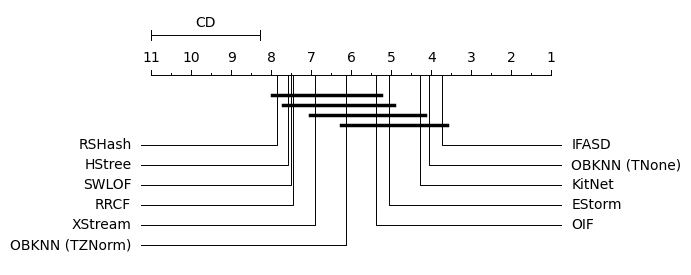

In [19]:
# Generate the report and the plot
# 'alpha' is the significance level
# 'verbose=False' suppresses console output of the report
# 'order='descending' because higher accuracy is better
mean_pivot = filtered_data.pivot_table(
    values="raw_pr_auc",
    index="cod_scenario",
    columns=["method"],
    aggfunc="mean"
)

result = autorank(mean_pivot, alpha=0.05, verbose=False, order='descending')
#print(result)

#create_report(result)


plot_stats(result, allow_insignificant=False)
#plt.savefig(current_dir / 'notebooks' / 'img_cdd'/ "cdd_all_methods.pdf", format="pdf", dpi=300, bbox_inches='tight')

plt.show()

In [20]:
# Pivot for mean - includes all data
mean_pivot = filtered_data.pivot_table(
    values="raw_pr_auc_wtd",
    columns=["cod_scenario", "window_size"],
    index=["method_and_year", "parameters"],
    aggfunc="mean"
)

# Pivot for std - includes all data
# Note: This will be NaN for all 'N' rows, which is correct.
std_pivot = filtered_data.pivot_table(
    values="raw_pr_auc_wtd",
    columns=["cod_scenario", "window_size"],
    index=["method_and_year", "parameters"],
    aggfunc="std"
)


# 2. Stack the DataFrames to align them as Series
mean_s = mean_pivot.stack(level=[0, 1], dropna=False)
std_s = std_pivot.stack(level=[0, 1], dropna=False)

# 3. Apply the formatting function row-by-row
combined_s = pd.DataFrame({'mean': mean_s, 'std': std_s}).apply(
    lambda row: format_mean_std(row['mean'], row['std']), 
    axis=1
)

# 4. Unstack back into a DataFrame
combined = combined_s.unstack(level=[-2, -1])
# Ensure column order is the same as the original pivot
if not combined.empty:
    combined = combined.reindex(columns=mean_pivot.columns)
else:
    # Handle case where combined might be empty
    combined = pd.DataFrame(index=mean_pivot.index, columns=mean_pivot.columns)


# Get the numeric averages first (for sorting and formatting)
avg_mean = mean_pivot.mean(axis=1)
avg_std = std_pivot.mean(axis=1) # This will be NaN for 'N' rows

# 5. Apply the same formatting logic to the Avg column
avg_col_s = pd.DataFrame({'mean': avg_mean, 'std': avg_std}).apply(
    lambda row: format_mean_std(row['mean'], row['std']),
    axis=1
)

combined["Avg"] = avg_col_s

# 6. Sort by the *numeric* average mean (before it was a string)
combined = combined.loc[avg_mean.sort_values(ascending=False).index]

# 7. Display with HTML formatting in Jupyter
combined

/tmp/ipykernel_3218468/1280918794.py:20: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  mean_s = mean_pivot.stack(level=[0, 1], dropna=False)
/tmp/ipykernel_3218468/1280918794.py:21: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  std_s = std_pivot.stack(level=[0, 1], dropna=False)


cod_scenario                                                                                                                                                                                                                                                                                                                                                         001  \
window_size                                                                                                                                                                                                                                                                                                                                                          324   
method_and_year       parameters                                                                                                                                                                                                                                                                                                                                           
OBKNN (TNone) (2025)  {'algorithm': 'brute', 'alpha_ema': 0.01, 'alpha_z_test': 0.05, 'chunk_size': 30, 'dmetric': 'cityblock', 'ensemble_size': 30, 'n_jobs': -1, 'no_bootstrapp': False, 'no_z_score': False, 'p_window_size': 0.2, 'transf': 'NONE', 'type_dist': 'largest', 'update_distance_with_abnormal': False, 'update_mode_stats': 'ema'}                  NaN   
IFASD (2013)          {'initial_window_X': None, 'p_window_size': 0.2}                                                                                                                                                                                                                                                                                               NaN   
KitNet (2018)         {'hidden_ratio': 0.9, 'learning_rate': 0.1, 'max_size_ae': 10, 'p_window_size': 0.05}                                                                                                                                                                                                                                                          NaN   
EStorm (2007)         {'max_radius': 900, 'p_window_size': 0.2}                                                                                                                                                                                                                                                                                                      NaN   
OBKNN (TZNorm) (2025) {'algorithm': 'brute', 'alpha_ema': 0.01, 'alpha_z_test': 0.05, 'chunk_size': 30, 'dmetric': 'cityblock', 'ensemble_size': 30, 'n_jobs': -1, 'no_bootstrapp': False, 'no_z_score': False, 'p_window_size': 0.2, 'transf': 'ZNORM', 'type_dist': 'largest', 'update_distance_with_abnormal': True, 'update_mode_stats': 'welford'}              NaN   
OIF (2024)            {'growth_criterion': 'fixed', 'max_leaf_samples': 64, 'n_jobs': -1, 'num_trees': 64, 'p_window_size': 0.2}                                                                                                                                                                                                                                     NaN   
XStream (2018)        {'depth': 25, 'n_chains': 100, 'num_components': 50, 'p_window_size': 0.02}                                                                                                                                                                                                                                                        0.014 ± 6.4e-04   
HStree (2011)         {'anomaly_threshold': 0.5, 'max_depth': 10, 'number_of_trees': 25, 'p_window_size': 0.02, 'size_limit': 0.1}                                                                                                                                                                                                                       0.009 ± 3.7e-03

                meanrank    median       mad  ci_lower  ci_upper effect_size  \
HStree          8.032258  0.071362  0.062264  0.009098  0.726407         0.0   
RRCF            7.774194  0.115055  0.040114  0.027664   0.18476   -0.562708   
RSHash          7.774194  0.073516  0.061716    0.0118  0.592822   -0.023439   
SWLOF           7.000000  0.113864  0.059947  0.034075  0.262624   -0.469063   
XStream         6.806452  0.168759  0.137365  0.027508  0.606774   -0.616009   
OIF             6.645161  0.192315  0.113256   0.02954  0.572652   -0.892692   
OBKNN (TZNorm)  5.903226  0.094915   0.06832  0.028693  0.921205   -0.243059   
EStorm          4.612903  0.511438  0.024276  0.067864  0.571429   -6.281375   
IFASD           3.967742  0.396518   0.39156  0.057354  0.997783   -0.782281   
KitNet          3.774194  0.405749  0.386488  0.034724  0.996247   -0.814782   
OBKNN (TNone)   3.709677  0.403319  0.400221  0.018417  0.999857   -0.781772   

                 magnitude effect_size_

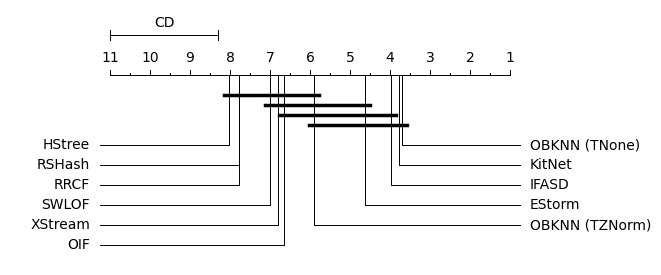

In [21]:
# Generate the report and the plot
# 'alpha' is the significance level
# 'verbose=False' suppresses console output of the report
# 'order='descending' because higher accuracy is better
mean_pivot = filtered_data.pivot_table(
    values="raw_pr_auc_wtd",
    index="cod_scenario",
    columns=["method"],
    aggfunc="mean"
)

result = autorank(mean_pivot, alpha=0.05, verbose=False, order='descending')
#print(result)

#create_report(result)


plot_stats(result, allow_insignificant=False)
#plt.savefig(current_dir / 'notebooks' / 'img_cdd'/ "cdd_all_methods.pdf", format="pdf", dpi=300, bbox_inches='tight')

plt.show()

In [22]:
# Pivot for mean - includes all data
mean_pivot = filtered_data.pivot_table(
    values="vus_pr",
    columns=["cod_scenario","window_size"],
    index=["method_and_year", "parameters"],
    aggfunc="mean"
)

# Pivot for std - includes all data
# Note: This will be NaN for all 'N' rows, which is correct.
std_pivot = filtered_data.pivot_table(
    values="vus_pr",
    columns=["cod_scenario", "window_size"],
    index=["method_and_year", "parameters"],
    aggfunc="std"
)


# 2. Stack the DataFrames to align them as Series
mean_s = mean_pivot.stack(level=[0, 1], dropna=False)
std_s = std_pivot.stack(level=[0, 1], dropna=False)

# 3. Apply the formatting function row-by-row
combined_s = pd.DataFrame({'mean': mean_s, 'std': std_s}).apply(
    lambda row: format_mean_std(row['mean'], row['std']), 
    axis=1
)

# 4. Unstack back into a DataFrame
combined = combined_s.unstack(level=[-2, -1])
# Ensure column order is the same as the original pivot
if not combined.empty:
    combined = combined.reindex(columns=mean_pivot.columns)
else:
    # Handle case where combined might be empty
    combined = pd.DataFrame(index=mean_pivot.index, columns=mean_pivot.columns)


# Get the numeric averages first (for sorting and formatting)
avg_mean = mean_pivot.mean(axis=1)
avg_std = std_pivot.mean(axis=1) # This will be NaN for 'N' rows

# 5. Apply the same formatting logic to the Avg column
avg_col_s = pd.DataFrame({'mean': avg_mean, 'std': avg_std}).apply(
    lambda row: format_mean_std(row['mean'], row['std']),
    axis=1
)

combined["Avg"] = avg_col_s

# 6. Sort by the *numeric* average mean (before it was a string)
combined = combined.loc[avg_mean.sort_values(ascending=False).index]

# 7. Display with HTML formatting in Jupyter
combined

/tmp/ipykernel_3218468/3280624656.py:20: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  mean_s = mean_pivot.stack(level=[0, 1], dropna=False)
/tmp/ipykernel_3218468/3280624656.py:21: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  std_s = std_pivot.stack(level=[0, 1], dropna=False)


cod_scenario                                                                                                                                                                                                                                                                                                                                                         001  \
window_size                                                                                                                                                                                                                                                                                                                                                          324   
method_and_year       parameters                                                                                                                                                                                                                                                                                                                                           
OBKNN (TNone) (2025)  {'algorithm': 'brute', 'alpha_ema': 0.01, 'alpha_z_test': 0.05, 'chunk_size': 30, 'dmetric': 'cityblock', 'ensemble_size': 30, 'n_jobs': -1, 'no_bootstrapp': False, 'no_z_score': False, 'p_window_size': 0.2, 'transf': 'NONE', 'type_dist': 'largest', 'update_distance_with_abnormal': False, 'update_mode_stats': 'ema'}                  NaN   
IFASD (2013)          {'initial_window_X': None, 'p_window_size': 0.2}                                                                                                                                                                                                                                                                                               NaN   
KitNet (2018)         {'hidden_ratio': 0.9, 'learning_rate': 0.1, 'max_size_ae': 10, 'p_window_size': 0.05}                                                                                                                                                                                                                                                          NaN   
OIF (2024)            {'growth_criterion': 'fixed', 'max_leaf_samples': 64, 'n_jobs': -1, 'num_trees': 64, 'p_window_size': 0.2}                                                                                                                                                                                                                                     NaN   
OBKNN (TZNorm) (2025) {'algorithm': 'brute', 'alpha_ema': 0.01, 'alpha_z_test': 0.05, 'chunk_size': 30, 'dmetric': 'cityblock', 'ensemble_size': 30, 'n_jobs': -1, 'no_bootstrapp': False, 'no_z_score': False, 'p_window_size': 0.2, 'transf': 'ZNORM', 'type_dist': 'largest', 'update_distance_with_abnormal': True, 'update_mode_stats': 'welford'}              NaN   
HStree (2011)         {'anomaly_threshold': 0.5, 'max_depth': 10, 'number_of_trees': 25, 'p_window_size': 0.02, 'size_limit': 0.1}                                                                                                                                                                                                                       0.026 ± 4.8e-03   
XStream (2018)        {'depth': 25, 'n_chains': 100, 'num_components': 50, 'p_window_size': 0.02}                                                                                                                                                                                                                                                        0.025 ± 1.6e-03   
SWLOF (2000)          {'k': 10, 'k_is_max': False, 'metric': 'euclidean', 'p_window_size': 0.02, 'simplified': False}                                                                                                                                                                                                                                    0.022 ± 1.2e-06

In [23]:

# 1. Pivot: REMOVED 'window_size'
# The pivot will now calculate the mean/std across all window sizes automatically.

mean_pivot = filtered_data.pivot_table(
    values="vus_pr",
    index=["code_and_name_scenario"],                           # <--- Rows: Datasets
    columns=["method_and_year", "parameters"],   # <--- Cols: Methods & Params only
    aggfunc="mean"
)

std_pivot = filtered_data.pivot_table(
    values="vus_pr",
    index=["code_and_name_scenario"],
    columns=["method_and_year", "parameters"],
    aggfunc="std"
)

# 2. Stack: We strictly have 2 levels of columns now
mean_s = mean_pivot.stack(level=[0, 1], dropna=False)
std_s = std_pivot.stack(level=[0, 1], dropna=False)

# 3. Format strings
combined_s = pd.DataFrame({'mean': mean_s, 'std': std_s}).apply(
    lambda row: format_mean_std(row['mean'], row['std']), 
    axis=1
)

# 4. Unstack: Restore the 2 column levels
combined = combined_s.unstack(level=[-2, -1])

# --- 5. HANDLING AVERAGES & SORTING ---

# Calculate the numeric average for the columns (axis=0)
avg_mean = mean_pivot.mean(axis=0)
avg_std = std_pivot.mean(axis=0)

# Sort columns by the method's average performance
sorted_columns = avg_mean.sort_values(ascending=False).index
combined = combined[sorted_columns]

# Format the Average Row
avg_row_s = pd.DataFrame({'mean': avg_mean, 'std': avg_std}).apply(
    lambda row: format_mean_std(row['mean'], row['std']),
    axis=1
)

# Add the "Avg" Row to the bottom
combined.loc['Average', :] = avg_row_s

# Display
combined

/tmp/ipykernel_3218468/3862296360.py:19: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  mean_s = mean_pivot.stack(level=[0, 1], dropna=False)
/tmp/ipykernel_3218468/3862296360.py:20: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  std_s = std_pivot.stack(level=[0, 1], dropna=False)


method_and_year,OBKNN (TNone) (2025),IFASD (2013),KitNet (2018),OIF (2024),OBKNN (TZNorm) (2025),HStree (2011),XStream (2018),SWLOF (2000),RRCF (2016),RSHash (2011),EStorm (2007)
parameters,"{'algorithm': 'brute', 'alpha_ema': 0.01, 'alpha_z_test': 0.05, 'chunk_size': 30, 'dmetric': 'cityblock', 'ensemble_size': 30, 'n_jobs': -1, 'no_bootstrapp': False, 'no_z_score': False, 'p_window_size': 0.2, 'transf': 'NONE', 'type_dist': 'largest', 'update_distance_with_abnormal': False, 'update_mode_stats': 'ema'}","{'initial_window_X': None, 'p_window_size': 0.2}","{'hidden_ratio': 0.9, 'learning_rate': 0.1, 'max_size_ae': 10, 'p_window_size': 0.05}","{'growth_criterion': 'fixed', 'max_leaf_samples': 64, 'n_jobs': -1, 'num_trees': 64, 'p_window_size': 0.2}","{'algorithm': 'brute', 'alpha_ema': 0.01, 'alpha_z_test': 0.05, 'chunk_size': 30, 'dmetric': 'cityblock', 'ensemble_size': 30, 'n_jobs': -1, 'no_bootstrapp': False, 'no_z_score': False, 'p_window_size': 0.2, 'transf': 'ZNORM', 'type_dist': 'largest', 'update_distance_with_abnormal': True, 'update_mode_stats': 'welford'}","{'anomaly_threshold': 0.5, 'max_depth': 10, 'number_of_trees': 25, 'p_window_size': 0.02, 'size_limit': 0.1}","{'depth': 25, 'n_chains': 100, 'num_components': 50, 'p_window_size': 0.02}","{'k': 10, 'k_is_max': False, 'metric': 'euclidean', 'p_window_size': 0.02, 'simplified': False}","{'num_trees': 4, 'p_window_size': 0.2, 'tree_size': 256}","{'decay': 0.05, 'feature_maxes': [inf, 2000], 'feature_mins': [0], 'num_components': 50, 'num_hash_fns': 1, 'p_window_size': 0.2}","{'max_radius': 900, 'p_window_size': 0.2}"
code_and_name_scenario,,,,,,,,,,,
001_Genesis,0.004 ± 6.3e-04,0.008 ± 6.4e-04,0.009 ± 0.0e+00,0.007 ± 2.0e-03,0.031 ± 9.5e-04,0.026 ± 4.8e-03,0.025 ± 1.6e-03,0.022 ± 1.2e-06,0.074 ± 2.3e-02,0.004 ± 0.0e+00,0.004 ± 0.0e+00
002_MSL,0.020 ± 1.9e-03,0.028 ± 4.2e-03,0.033 ± 0.0e+00,0.025 ± 8.2e-03,0.075 ± 1.5e-02,0.005 ± 1.9e-04,0.020 ± 8.2e-03,0.026 ± 0.0e+00,0.045 ± 1.0e-02,0.036 ± 0.0e+00,0.010 ± 0.0e+00
018_Daphnet,0.078 ± 1.7e-03,0.389 ± 9.9e-03,0.393 ± 0.0e+00,0.143 ± 3.4e-03,0.100 ± 6.5e-04,0.044 ± 1.2e-04,0.037 ± 1.3e-04,0.150 ± 1.9e-05,0.128 ± 2.1e-03,0.048 ± 0.0e+00,0.064 ± 0.0e+00
032_GHL,0.015 ± 1.7e-04,0.009 ± 6.8e-04,0.011 ± 0.0e+00,0.008 ± 6.4e-04,0.014 ± 4.6e-05,0.013 ± 2.3e-03,0.028 ± 6.7e-03,0.014 ± 0.0e+00,0.017 ± 4.1e-04,0.017 ± 0.0e+00,0.015 ± 0.0e+00
057_SMD,0.257 ± 4.7e-02,0.274 ± 3.3e-03,0.313 ± 0.0e+00,0.195 ± 3.1e-02,0.270 ± 1.2e-03,0.016 ± 6.8e-05,0.285 ± 3.4e-02,0.062 ± 0.0e+00,0.078 ± 7.3e-03,0.019 ± 1.6e-04,0.036 ± 0.0e+00
115_PSM,0.152 ± 6.1e-03,0.153 ± 2.6e-03,0.142 ± 0.0e+00,0.167 ± 3.3e-03,0.162 ± 7.4e-04,0.082 ± 8.1e-03,0.101 ± 4.5e-03,0.124 ± 0.0e+00,0.145 ± 1.6e-03,0.141 ± 1.3e-02,0.141 ± 0.0e+00
117_TAO,0.924 ± 6.8e-03,0.512 ± 5.1e-02,0.993 ± 0.0e+00,1.000 ± 1.9e-05,0.845 ± 8.7e-02,0.096 ± 8.1e-05,0.605 ± 8.6e-02,0.203 ± 1.2e-03,0.277 ± 3.6e-02,0.098 ± 3.0e-05,0.139 ± 0.0e+00
129_OPPORTUNITY,0.012 ± 5.9e-04,0.120 ± 5.7e-02,0.024 ± 0.0e+00,0.035 ± 1.3e-02,0.016 ± 2.0e-04,0.022 ± 2.8e-03,0.061 ± 4.3e-03,0.059 ± 0.0e+00,0.036 ± 4.9e-03,0.028 ± 0.0e+00,0.053 ± 0.0e+00


                meanrank    median       mad  ci_lower  ci_upper effect_size  \
RSHash          8.645161  0.091268  0.067182  0.015358   0.26545         0.0   
EStorm          8.612903  0.127573  0.102208  0.014894  0.255337   -0.283136   
HStree          7.516129  0.095404  0.079437  0.015967  0.962575   -0.037921   
SWLOF           6.903226  0.165149  0.059447  0.036352  0.270644   -0.785596   
RRCF            6.419355  0.152213  0.073558  0.035703  0.301541   -0.583555   
XStream         6.322581  0.205088  0.167501  0.033233  0.676749   -0.601589   
OBKNN (TZNorm)  5.354839  0.207744  0.176376  0.031368  0.920683   -0.588663   
OIF             4.645161  0.326483  0.287418  0.034934  0.981454   -0.760136   
KitNet          4.419355  0.431448  0.407571  0.028586   0.99661   -0.785552   
OBKNN (TNone)   3.870968  0.538990   0.46041  0.019934  0.999924   -0.917867   
IFASD           3.290323  0.526711  0.440115  0.038644  0.999787   -0.932943   

                 magnitude effect_size_

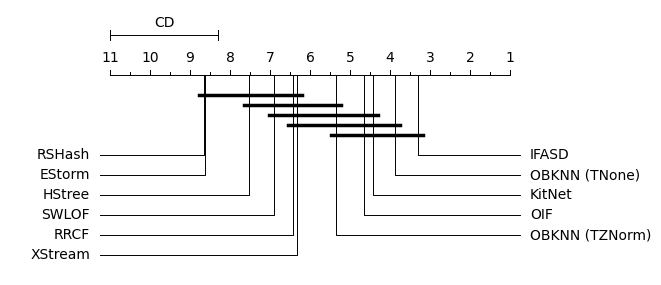

In [24]:
# Generate the report and the plot
# 'alpha' is the significance level
# 'verbose=False' suppresses console output of the report
# 'order='descending' because higher accuracy is better
mean_pivot = filtered_data.pivot_table(
    values="vus_pr",
    index="cod_scenario",
    columns=["method"],
    aggfunc="mean"
)

result = autorank(mean_pivot, alpha=0.05, verbose=False, order='descending')
#print(result)

#create_report(result)


plot_stats(result, allow_insignificant=False)
#plt.savefig(current_dir / 'notebooks' / 'img_cdd'/ "cdd_all_methods.pdf", format="pdf", dpi=300, bbox_inches='tight')

plt.show()

In [25]:
# Pivot for mean - includes all data
mean_pivot = filtered_data.pivot_table(
    values="auc_roc",
    columns=["cod_scenario", "window_size"],
    index=["method_and_year", "parameters"],
    aggfunc="mean"
)

# Pivot for std - includes all data
# Note: This will be NaN for all 'N' rows, which is correct.
std_pivot = filtered_data.pivot_table(
    values="auc_roc",
    columns=["cod_scenario", "window_size"],
    index=["method_and_year", "parameters"],
    aggfunc="std"
)


# 2. Stack the DataFrames to align them as Series
mean_s = mean_pivot.stack(level=[0, 1], dropna=False)
std_s = std_pivot.stack(level=[0, 1], dropna=False)

# 3. Apply the formatting function row-by-row
combined_s = pd.DataFrame({'mean': mean_s, 'std': std_s}).apply(
    lambda row: format_mean_std(row['mean'], row['std']), 
    axis=1
)

# 4. Unstack back into a DataFrame
combined = combined_s.unstack(level=[-2, -1])
# Ensure column order is the same as the original pivot
if not combined.empty:
    combined = combined.reindex(columns=mean_pivot.columns)
else:
    # Handle case where combined might be empty
    combined = pd.DataFrame(index=mean_pivot.index, columns=mean_pivot.columns)


# Get the numeric averages first (for sorting and formatting)
avg_mean = mean_pivot.mean(axis=1)
avg_std = std_pivot.mean(axis=1) # This will be NaN for 'N' rows

# 5. Apply the same formatting logic to the Avg column
avg_col_s = pd.DataFrame({'mean': avg_mean, 'std': avg_std}).apply(
    lambda row: format_mean_std(row['mean'], row['std']),
    axis=1
)

combined["Avg"] = avg_col_s

# 6. Sort by the *numeric* average mean (before it was a string)
combined = combined.loc[avg_mean.sort_values(ascending=False).index]

# 7. Display with HTML formatting in Jupyter
combined

/tmp/ipykernel_3218468/3052700536.py:20: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  mean_s = mean_pivot.stack(level=[0, 1], dropna=False)
/tmp/ipykernel_3218468/3052700536.py:21: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  std_s = std_pivot.stack(level=[0, 1], dropna=False)


cod_scenario                                                                                                                                                                                                                                                                                                                                                         001  \
window_size                                                                                                                                                                                                                                                                                                                                                          324   
method_and_year       parameters                                                                                                                                                                                                                                                                                                                                           
IFASD (2013)          {'initial_window_X': None, 'p_window_size': 0.2}                                                                                                                                                                                                                                                                                               NaN   
KitNet (2018)         {'hidden_ratio': 0.9, 'learning_rate': 0.1, 'max_size_ae': 10, 'p_window_size': 0.05}                                                                                                                                                                                                                                                          NaN   
OBKNN (TNone) (2025)  {'algorithm': 'brute', 'alpha_ema': 0.01, 'alpha_z_test': 0.05, 'chunk_size': 30, 'dmetric': 'cityblock', 'ensemble_size': 30, 'n_jobs': -1, 'no_bootstrapp': False, 'no_z_score': False, 'p_window_size': 0.2, 'transf': 'NONE', 'type_dist': 'largest', 'update_distance_with_abnormal': False, 'update_mode_stats': 'ema'}                  NaN   
OIF (2024)            {'growth_criterion': 'fixed', 'max_leaf_samples': 64, 'n_jobs': -1, 'num_trees': 64, 'p_window_size': 0.2}                                                                                                                                                                                                                                     NaN   
XStream (2018)        {'depth': 25, 'n_chains': 100, 'num_components': 50, 'p_window_size': 0.02}                                                                                                                                                                                                                                                        0.879 ± 1.1e-02   
RRCF (2016)           {'num_trees': 4, 'p_window_size': 0.2, 'tree_size': 256}                                                                                                                                                                                                                                                                                       NaN   
OBKNN (TZNorm) (2025) {'algorithm': 'brute', 'alpha_ema': 0.01, 'alpha_z_test': 0.05, 'chunk_size': 30, 'dmetric': 'cityblock', 'ensemble_size': 30, 'n_jobs': -1, 'no_bootstrapp': False, 'no_z_score': False, 'p_window_size': 0.2, 'transf': 'ZNORM', 'type_dist': 'largest', 'update_distance_with_abnormal': True, 'update_mode_stats': 'welford'}              NaN   
SWLOF (2000)          {'k': 10, 'k_is_max': False, 'metric': 'euclidean', 'p_window_size': 0.02, 'simplified': False}                                                                                                                                                                                                                                    0.763 ± 2.0e-05

In [26]:
try:
    filtered_data = filtered_data[filtered_data.cod_scenario.isin(["RMX"])]# filtered dataset since it is the closest to real life
    filtered_data = filtered_data[filtered_data.method.str.contains("SFOBKNN|SFRSHash")]

    # Pivot with both mean and std at once

    pivot = filtered_data.pivot_table(
        values=["tn","tp","fn","fp","best_threshold","raw_pct_detection","raw_pct_false_positives","raw_max_f1","raw_pr_auc"],
        columns=["cod_scenario", "window_size"],
        index=["method_and_year", "parameters"],
        aggfunc=["mean", "std"]
    )

    # Create a new empty DataFrame for the strings
    combined = pd.DataFrame(index=pivot.index)

    # Loop through the scenarios and windows to combine mean and std
    # pivot['mean'].columns gives the (scenario, window) pairs
    for col in pivot['mean'].columns:
        combined[col] = [
            format_mean_std(m, s) 
            for m, s in zip(pivot[('mean', *col)], pivot[('std', *col)])
        ]

    combined
except Exception as e:
    print(f"Error during pivoting and formatting: {e}")

Error during pivoting and formatting: 'mean'


## Summary Training Time of Online Anomaly Detectors with PV Datasets 

In [27]:
# Pivot for mean - includes all data
mean_pivot = filtered_data.pivot_table(
    values="mean_training_time",
    columns=["cod_scenario", "window_size"],
    index=["method_and_year", "parameters"],
    aggfunc="mean"
)

# Pivot for std - includes all data
# Note: This will be NaN for all 'N' rows, which is correct.
std_pivot = filtered_data.pivot_table(
    values="mean_training_time",
    columns=["cod_scenario", "window_size"],
    index=["method_and_year", "parameters"],
    aggfunc="std"
)


# 2. Stack the DataFrames to align them as Series
mean_s = mean_pivot.stack(level=[0, 1], dropna=False)
std_s = std_pivot.stack(level=[0, 1], dropna=False)

# 3. Apply the formatting function row-by-row
combined_s = pd.DataFrame({'mean': mean_s, 'std': std_s}).apply(
    lambda row: format_mean_std(row['mean'], row['std']), 
    axis=1
)

# 4. Unstack back into a DataFrame
combined = combined_s.unstack(level=[-2, -1])
# Ensure column order is the same as the original pivot
if not combined.empty:
    combined = combined.reindex(columns=mean_pivot.columns)
else:
    # Handle case where combined might be empty
    combined = pd.DataFrame(index=mean_pivot.index, columns=mean_pivot.columns)


# Get the numeric averages first (for sorting and formatting)
avg_mean = mean_pivot.mean(axis=1)
avg_std = std_pivot.mean(axis=1) # This will be NaN for 'N' rows

# 5. Apply the same formatting logic to the Avg column
avg_col_s = pd.DataFrame({'mean': avg_mean, 'std': avg_std}).apply(
    lambda row: format_mean_std(row['mean'], row['std']),
    axis=1
)

combined["Avg"] = avg_col_s

# 6. Sort by the *numeric* average mean (before it was a string)
combined = combined.loc[avg_mean.sort_values(ascending=False).index]

# 7. Display with HTML formatting in Jupyter
combined

/tmp/ipykernel_3218468/1826925235.py:20: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  mean_s = mean_pivot.stack(level=[0, 1], dropna=False)
/tmp/ipykernel_3218468/1826925235.py:21: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  std_s = std_pivot.stack(level=[0, 1], dropna=False)


,cod_scenario,Avg
,window_size,
method_and_year,parameters,


## Summary Scoring Time of Online Anomaly Detectors with PV Datasets 

In [28]:
# Pivot for mean - includes all data
mean_pivot = filtered_data.pivot_table(
    values="mean_scoring_time",
    columns=["cod_scenario", "window_size"],
    index=["method_and_year", "parameters"],
    aggfunc="mean"
)

# Pivot for std - includes all data
# Note: This will be NaN for all 'N' rows, which is correct.
std_pivot = filtered_data.pivot_table(
    values="mean_scoring_time",
    columns=["cod_scenario", "window_size"],
    index=["method_and_year", "parameters"],
    aggfunc="std"
)


# 2. Stack the DataFrames to align them as Series
mean_s = mean_pivot.stack(level=[0, 1], dropna=False)
std_s = std_pivot.stack(level=[0, 1], dropna=False)

# 3. Apply the formatting function row-by-row
combined_s = pd.DataFrame({'mean': mean_s, 'std': std_s}).apply(
    lambda row: format_mean_std(row['mean'], row['std']), 
    axis=1
)

# 4. Unstack back into a DataFrame
combined = combined_s.unstack(level=[-2, -1])
# Ensure column order is the same as the original pivot
if not combined.empty:
    combined = combined.reindex(columns=mean_pivot.columns)
else:
    # Handle case where combined might be empty
    combined = pd.DataFrame(index=mean_pivot.index, columns=mean_pivot.columns)


# Get the numeric averages first (for sorting and formatting)
avg_mean = mean_pivot.mean(axis=1)
avg_std = std_pivot.mean(axis=1) # This will be NaN for 'N' rows

# 5. Apply the same formatting logic to the Avg column
avg_col_s = pd.DataFrame({'mean': avg_mean, 'std': avg_std}).apply(
    lambda row: format_mean_std(row['mean'], row['std']),
    axis=1
)

combined["Avg"] = avg_col_s

# 6. Sort by the *numeric* average mean (before it was a string)
combined = combined.loc[avg_mean.sort_values(ascending=False).index]

# 7. Display with HTML formatting in Jupyter
combined

/tmp/ipykernel_3218468/3238025577.py:20: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  mean_s = mean_pivot.stack(level=[0, 1], dropna=False)
/tmp/ipykernel_3218468/3238025577.py:21: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  std_s = std_pivot.stack(level=[0, 1], dropna=False)


,cod_scenario,Avg
,window_size,
method_and_year,parameters,
